In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import kalman
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

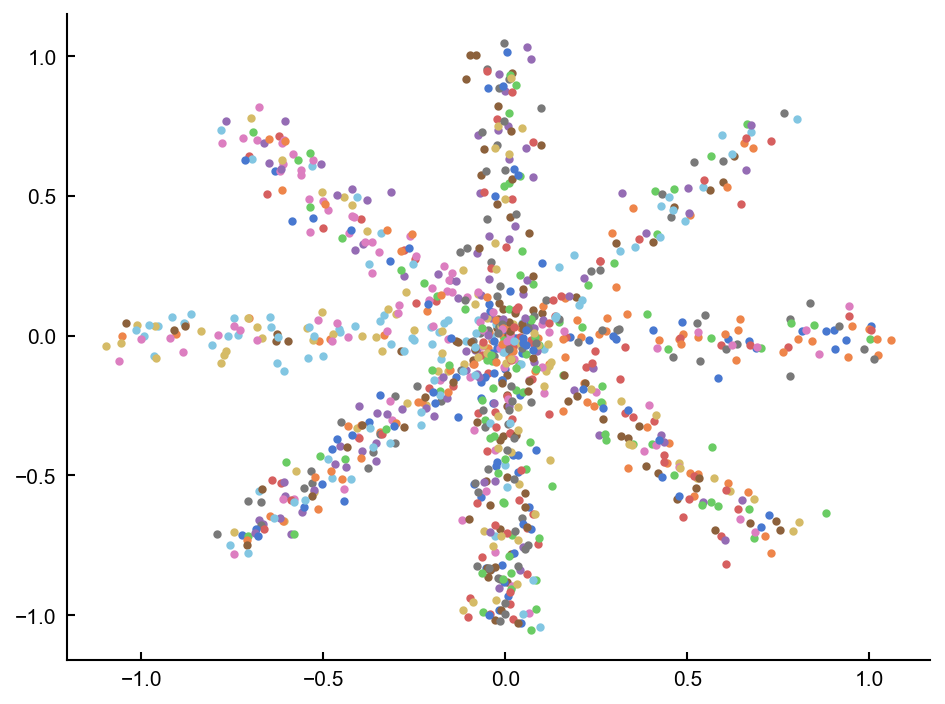

In [15]:
thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
n_trials = 100
noise = 0.05
T = 10
r = np.linspace(0, 1, T)
X = np.zeros((n_trials, T, 2, 1))
for n in range(n_trials):
    theta = np.random.choice(thetas)
    # for i, theta in enumerate(thetas):
    x = r * np.cos(theta) + np.random.normal(0, noise, T)
    y = r * np.sin(theta) + np.random.normal(0, noise, T)
    X[n] = np.array([x, y]).T[..., None]
    plt.plot(x, y,  '.')

In [16]:
reload(kalman)

<module 'pillow_lab_rotation.kalman' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/kalman.py'>

In [17]:
lds = kalman.LinearDynamicalSystem(2, 2)

In [18]:
lds.fit(X)

-0.43347
0.37017
0.99987
1.46831
1.79119
1.98283
2.07843
2.11989
2.13718
2.14510
2.14938
2.15203
2.15382
2.15506
2.15596
2.15662
2.15710
2.15747
2.15776
2.15798
2.15815
2.15829
2.15840
2.15849
2.15857
2.15863
2.15867
2.15872
2.15875
2.15878
2.15880
2.15882
2.15884
2.15885
2.15886
2.15887


In [19]:
pred_means, pred_covs, obs_mean, obs_cov, post_means, post_covs = lds.predict(X)

In [37]:
def plot_confidence_ellipse(M, V):
    """
    Plot a one standard-deviation ellipse for a N-dimensional Gaussian distribution.
    Arguments:
        M: mean of the Gaussian (N x 1) 
        V: Covariance matrix of the Gaussian (N x N)

    We've provided this function for you. Feel free to use it as is to help plot 
    the one standard-deviation confidence ellipse for each position estimate, modify it
    to your liking, or write your own function.

    Code adapted from EM_GM.m by Patrick P. C. Tsui.
    """
    eigenvals, eigenvecs = np.linalg.eig(V)
    d = len(M)
    if not np.any(V): # if V is array of all zeros
        V[:, :] = np.ones((d,d))  * np.finfo(float).eps
    inv_V = np.linalg.inv(V)

    # find the larger projection
    P = np.array([[1,0], [0,0]]) # X-axis projection operator
    P1 = P @ np.reshape((2 * np.sqrt(eigenvals[0]) * eigenvecs[:,0]), (2,1))
    P2 = P @ np.reshape((2 * np.sqrt(eigenvals[1]) * eigenvecs[:,1]), (2,1))
    if (np.all(np.abs(P1) >= np.abs(P2))):
        P_len = P1[0, 0]
    else:
        P_len = P2[0, 0]
    
    count = 0
    step = 0.001 * P_len
    contour_1 = np.zeros((2001,2))
    contour_2 = np.zeros((2001,2))

    for x in np.arange(-P_len, P_len + step, step):
        a = inv_V[1,1]
        b = x * (inv_V[0, 1] + inv_V[1, 0])
        c = x**2 * inv_V[0,0] - 1
        disc = b**2 - 4*a*c 

        if disc >= 0:
            root_1 = (-b + np.sqrt(disc)) / (2*a)
            root_2 = (-b - np.sqrt(disc)) / (2*a)
            if np.isreal(root_1):
                contour_1[count, :] = [x, root_1] + M.T
                contour_2[count, :] = [x, root_2] + M.T
                count += 1
    
    contour_1 = contour_1[0:count-1, :]
    contour_2 = np.vstack((contour_1[0], contour_2[0:count, :], contour_1[count-2, :]))

    plt.plot(M[0], M[1], 'r+')
    plt.plot(contour_1[:,0], contour_1[:,1], 'b-', linewidth=0.5, c='k')
    plt.plot(contour_2[:,0], contour_2[:,1], 'b-', linewidth=0.5, c='k')

/var/folders/48/jp5t51cd1b77fn50_y71wwlw0000gn/T/ipykernel_45078/2328967102.py:52: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_1[:,0], contour_1[:,1], 'b-', linewidth=0.5, c='k')
/var/folders/48/jp5t51cd1b77fn50_y71wwlw0000gn/T/ipykernel_45078/2328967102.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(contour_2[:,0], contour_2[:,1], 'b-', linewidth=0.5, c='k')


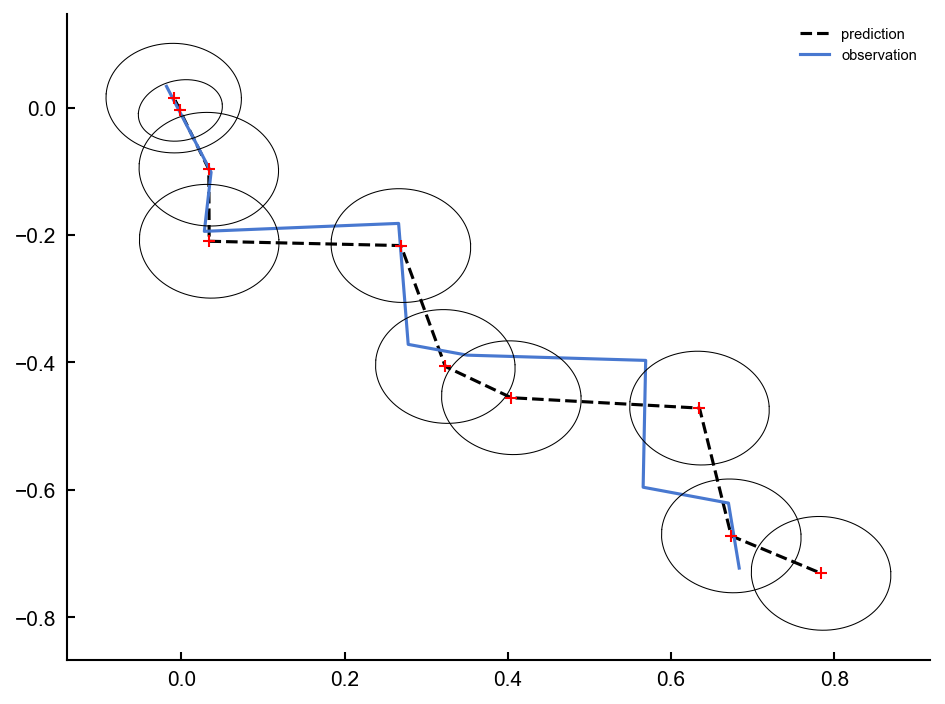

In [46]:

trial = 12

plt.plot(obs_mean[trial, :, 0, 0], obs_mean[trial, :, 1, 0], linestyle='--', label='prediction', c='k')
plt.plot(X[trial, :, 0, 0], X[trial, :, 1, 0], label='observation')
for t in range(T):
    plot_confidence_ellipse(obs_mean[trial, t, :, 0], obs_cov[trial, t])

plt.legend()

In [22]:
X.shape

(100, 10, 2, 1)

In [23]:
X[40, :, 0].shape

(10, 1)